## 2. Задание

### 2.3.1 Импорты, seed и устройство

Импортируем библиотеки, фиксируем seed для воспроизводимости и определяем устройство.


In [39]:
import os
import json
import copy
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# Seed — фиксируем везде
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Устройство: CUDA → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch {torch.__version__} | torchvision {torchvision.__version__}')
print(f'Device : {device}')
print(f'Seed   : {SEED}')

# Пути к артефактам
ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

PyTorch 2.10.0 | torchvision 0.25.0
Device : mps
Seed   : 42


### 2.3.2 Данные и DataLoader

Загружаем **EMNIST balanced** из `torchvision`, делаем воспроизводимое разбиение train/val (80/20) и создаём DataLoader-ы.

**EMNIST balanced** содержит:
- 47 классов: 10 цифр (0–9) + 37 букв
- Изображения 28×28 пикселей, оттенки серого
- ~112 800 train / ~18 800 test

> **Важно:** разбиение `train/val` фиксируется через `torch.Generator().manual_seed(SEED)` — одинаковый split при каждом запуске.

In [ ]:
DATASET_NAME = 'EMNIST'
BATCH_SIZE   = 128
VAL_RATIO    = 0.2

# Нормализация: mean=0.1307, std=0.3081 — стандарт для MNIST-семейства
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True,
                                          download=True, transform=transform)
test_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False,
                                            download=True, transform=transform)

# Воспроизводимое разбиение train / val
n_val   = int(len(full_train) * VAL_RATIO)
n_train = len(full_train) - n_val
train_dataset, val_dataset = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f'x.shape: {x_batch.shape}, y.shape: {y_batch.shape}')
print(f'x range: [{x_batch.min():.2f}, {x_batch.max():.2f}]')
print(f'Num classes: {len(full_train.classes)}')

NUM_CLASSES = len(full_train.classes)
INPUT_SIZE  = 28 * 28

Train: 90240, Val: 22560, Test: 18800
x.shape: torch.Size([128, 1, 28, 28]), y.shape: torch.Size([128])
x range: [-0.42, 2.82]
Num classes: 47


### 2.3.3 Модель MLP и цикл обучения

Реализуем:
- `MLP` — гибкий `nn.Module` с поддержкой Dropout и BatchNorm
- `train_one_epoch()` — один шаг обучения с `model.train()`
- `evaluate()` — валидация/тест с `model.eval()` и `@torch.no_grad()`
- `EarlyStopping` — отдельный класс для ранней остановки
- `run_experiment()` — полный цикл обучения, возвращает `(history, best_val_loss, best_val_acc)`

| Приём | Зачем |
|-------|-------|
| `model.train()` / `model.eval()` | Переключает поведение Dropout и BatchNorm |
| `@torch.no_grad()` | Отключает граф вычислений при инференсе — экономит память |
| `zero_grad(set_to_none=True)` | Освобождает память эффективнее, чем обнуление |
| `non_blocking=True` | Асинхронная пересылка данных на GPU |
| `copy.deepcopy(state_dict)` | Глубокая копия весов без риска перезаписи |
| `EarlyStopping` как класс | Чистая инкапсуляция логики — легко переиспользовать |

In [40]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        in_features = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        # non_blocking=True — асинхронная пересылка на GPU
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # эффективнее обнуления
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y   = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


class EarlyStopping:
    """Останавливает обучение, если val_acc не улучшается patience эпох подряд."""
    def __init__(self, patience=5, min_delta=0.0):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.best_state = None
        self.counter    = 0

    def step(self, score: float, model: nn.Module) -> bool:
        """Возвращает True, если нужно остановиться."""
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_experiment(model, train_loader, val_loader, criterion,
                   optimizer, epochs, device, early_stopping=None):
    """
    Полный цикл обучения с опциональным EarlyStopping.

    Returns:
        history       : dict с per-epoch train/val loss и accuracy
        best_val_loss : val_loss чекпоинта, сохранённого в модели
        best_val_acc  : val_acc той же эпохи (согласованная пара)
    """
    history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_val_acc  = 0.0
    best_state    = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc   = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        # Чекпоинт по val_loss — метрики из одной эпохи (согласованная пара)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = val_acc
            best_state    = copy.deepcopy(model.state_dict())
            tag = ' ★'

        print(f'Epoch {epoch:3d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
              f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f}{tag}')

        # EarlyStopping по val_acc
        if early_stopping is not None:
            if early_stopping.step(val_acc, model):
                print(f'  Early stopping на эпохе {epoch}. '
                      f'Лучший val_acc={early_stopping.best_score:.4f}')
                early_stopping.restore_best(model)
                # Синхронизируем best_state с весами ES
                best_state    = copy.deepcopy(model.state_dict())
                best_val_acc  = early_stopping.best_score
                break

    # Восстанавливаем лучший чекпоинт
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_loss, best_val_acc


print('Классы и функции определены.')

Классы и функции определены.


---

## 3. Эксперименты

Задаём общие гиперпараметры. Все эксперименты E1–E3 используют одинаковые настройки для честного сравнения.

In [41]:
HIDDEN_SIZES  = [512, 256, 128]   # 3 скрытых слоя — «MLP побольше» по заданию
EPOCHS_PART_A = 15
LR_BASE       = 1e-3
criterion     = nn.CrossEntropyLoss()

all_histories = {}
results       = []   # строки для runs.csv

print(f'Архитектура: {HIDDEN_SIZES}, эпох: {EPOCHS_PART_A}, lr: {LR_BASE}')

Архитектура: [512, 256, 128], эпох: 15, lr: 0.001


### 3.1 Часть A (S08): регуляризация и переобучение (E1–E4)

| Эксперимент | Конфиг | Цель |
|-------------|--------|------|
| E1 (base) | Без регуляризации | Базовая линия, ожидаем переобучение |
| E2 (Dropout) | Dropout(p=0.3) | Снизить переобучение |
| E3 (BatchNorm) | BatchNorm1d | Стабилизировать обучение |
| E4 (Best+ES) | Лучший из E2/E3 + patience=5 | Остановка в оптимальный момент |

#### E1 — Base (без Dropout, без BatchNorm)

MLP [512, 256, 128], ReLU, без регуляризации. Обучаем 15 эпох с Adam (lr=1e-3).

**Ожидание:** без регуляризации модель будет переобучаться — train loss падает, val loss выходит на плато или растёт.

In [42]:
torch.manual_seed(SEED)
model_e1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=0.0, use_batchnorm=False).to(device)
opt_e1 = optim.Adam(model_e1.parameters(), lr=LR_BASE)

print('=== E1: Base ===')
hist_e1, best_val_loss_e1, best_val_acc_e1 = run_experiment(
    model_e1, train_loader, val_loader, criterion, opt_e1, EPOCHS_PART_A, device
)
all_histories['E1'] = hist_e1
print(f'E1 best val_acc: {best_val_acc_e1:.4f}')

results.append({
    'experiment_id': 'E1', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': '512-256-128/ReLU/no_dropout/no_BN',
    'optimizer': 'Adam', 'lr': LR_BASE, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e1['train_loss']),
    'best_val_accuracy': round(best_val_acc_e1, 4),
    'best_val_loss': round(best_val_loss_e1, 4)
})

=== E1: Base ===
Epoch   1 | tr_loss=1.0050 tr_acc=0.6795 | val_loss=0.6750 val_acc=0.7704 ★
Epoch   2 | tr_loss=0.5785 tr_acc=0.7942 | val_loss=0.6057 val_acc=0.7929 ★
Epoch   3 | tr_loss=0.4940 tr_acc=0.8188 | val_loss=0.5541 val_acc=0.8063 ★
Epoch   4 | tr_loss=0.4325 tr_acc=0.8335 | val_loss=0.5407 val_acc=0.8132 ★
Epoch   5 | tr_loss=0.3925 tr_acc=0.8443 | val_loss=0.5253 val_acc=0.8157 ★
Epoch   6 | tr_loss=0.3730 tr_acc=0.8505 | val_loss=0.5420 val_acc=0.8141
Epoch   7 | tr_loss=0.3505 tr_acc=0.8585 | val_loss=0.5436 val_acc=0.8148
Epoch   8 | tr_loss=0.3177 tr_acc=0.8660 | val_loss=0.5615 val_acc=0.8126
Epoch   9 | tr_loss=0.3133 tr_acc=0.8716 | val_loss=0.5384 val_acc=0.8208
Epoch  10 | tr_loss=0.2841 tr_acc=0.8771 | val_loss=0.5607 val_acc=0.8190
Epoch  11 | tr_loss=0.2868 tr_acc=0.8813 | val_loss=0.5424 val_acc=0.8223
Epoch  12 | tr_loss=0.2673 tr_acc=0.8848 | val_loss=0.5774 val_acc=0.8172
Epoch  13 | tr_loss=0.2606 tr_acc=0.8892 | val_loss=0.5859 val_acc=0.8178
Epoch  14 |

#### E2 — Dropout (p=0.3)

Та же MLP [512, 256, 128], но после каждого ReLU — `Dropout(p=0.3)`.

**Как работает Dropout:** во время обучения случайно обнуляет 30% нейронов в каждом батче. Модель не может полагаться на отдельные нейроны → лучше обобщение. На инференсе (`model.eval()`) все нейроны активны.

**Ожидание:** меньший gap между train/val метриками по сравнению с E1.

In [43]:
torch.manual_seed(SEED)
model_e2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=0.3, use_batchnorm=False).to(device)
opt_e2 = optim.Adam(model_e2.parameters(), lr=LR_BASE)

print('=== E2: Dropout p=0.3 ===')
hist_e2, best_val_loss_e2, best_val_acc_e2 = run_experiment(
    model_e2, train_loader, val_loader, criterion, opt_e2, EPOCHS_PART_A, device
)
all_histories['E2'] = hist_e2
print(f'E2 best val_acc: {best_val_acc_e2:.4f}')

results.append({
    'experiment_id': 'E2', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': '512-256-128/ReLU/dropout=0.3/no_BN',
    'optimizer': 'Adam', 'lr': LR_BASE, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e2['train_loss']),
    'best_val_accuracy': round(best_val_acc_e2, 4),
    'best_val_loss': round(best_val_loss_e2, 4)
})

=== E2: Dropout p=0.3 ===
Epoch   1 | tr_loss=1.0933 tr_acc=0.4060 | val_loss=0.6414 val_acc=0.5721 ★
Epoch   2 | tr_loss=0.6387 tr_acc=0.4852 | val_loss=0.5167 val_acc=0.5933 ★
Epoch   3 | tr_loss=0.6742 tr_acc=0.5980 | val_loss=0.6225 val_acc=0.7604
Epoch   4 | tr_loss=0.5993 tr_acc=0.5942 | val_loss=0.5208 val_acc=0.6890
Epoch   5 | tr_loss=0.5155 tr_acc=0.5416 | val_loss=0.5673 val_acc=0.7978
Epoch   6 | tr_loss=0.6024 tr_acc=0.6709 | val_loss=0.4270 val_acc=0.6260 ★
Epoch   7 | tr_loss=0.5191 tr_acc=0.6010 | val_loss=0.4509 val_acc=0.6624
Epoch   8 | tr_loss=0.4656 tr_acc=0.5405 | val_loss=0.4593 val_acc=0.6578
Epoch   9 | tr_loss=0.4248 tr_acc=0.5188 | val_loss=0.4267 val_acc=0.6420 ★
Epoch  10 | tr_loss=0.4775 tr_acc=0.5288 | val_loss=0.4171 val_acc=0.6220 ★
Epoch  11 | tr_loss=0.4943 tr_acc=0.6218 | val_loss=0.4647 val_acc=0.7286
Epoch  12 | tr_loss=0.4931 tr_acc=0.6444 | val_loss=0.3881 val_acc=0.5990 ★
Epoch  13 | tr_loss=0.5275 tr_acc=0.7268 | val_loss=0.4941 val_acc=0.7660


#### E3 — BatchNorm

Та же MLP [512, 256, 128], но с `BatchNorm1d` после каждого Linear (перед ReLU). Без Dropout.

**Как работает BatchNorm:** нормализует активации по батчу `(x - mean) / std`, добавляет обучаемые `gamma` и `beta`. Снижает internal covariate shift → стабильнее градиенты, можно учиться быстрее.

**Ожидание:** более стабильные кривые loss, быстрее сходимость.

In [44]:
torch.manual_seed(SEED)
model_e3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=0.0, use_batchnorm=True).to(device)
opt_e3 = optim.Adam(model_e3.parameters(), lr=LR_BASE)

print('=== E3: BatchNorm ===')
hist_e3, best_val_loss_e3, best_val_acc_e3 = run_experiment(
    model_e3, train_loader, val_loader, criterion, opt_e3, EPOCHS_PART_A, device
)
all_histories['E3'] = hist_e3
print(f'E3 best val_acc: {best_val_acc_e3:.4f}')

results.append({
    'experiment_id': 'E3', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': '512-256-128/ReLU/no_dropout/BN',
    'optimizer': 'Adam', 'lr': LR_BASE, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_e3['train_loss']),
    'best_val_accuracy': round(best_val_acc_e3, 4),
    'best_val_loss': round(best_val_loss_e3, 4)
})

=== E3: BatchNorm ===
Epoch   1 | tr_loss=0.9693 tr_acc=0.6242 | val_loss=0.5382 val_acc=0.7001 ★
Epoch   2 | tr_loss=0.5816 tr_acc=0.6798 | val_loss=0.2037 val_acc=0.3116 ★
Epoch   3 | tr_loss=0.3597 tr_acc=0.5638 | val_loss=0.3335 val_acc=0.5480
Epoch   4 | tr_loss=0.4943 tr_acc=0.8036 | val_loss=0.3958 val_acc=0.5811
Epoch   5 | tr_loss=0.4865 tr_acc=0.7733 | val_loss=0.3131 val_acc=0.5943
Epoch   6 | tr_loss=0.5432 tr_acc=0.7143 | val_loss=0.3269 val_acc=0.5003
Epoch   7 | tr_loss=0.5903 tr_acc=0.7393 | val_loss=0.3812 val_acc=0.6802
Epoch   8 | tr_loss=0.5793 tr_acc=0.7331 | val_loss=0.4286 val_acc=0.4358
Epoch   9 | tr_loss=0.5300 tr_acc=0.7267 | val_loss=0.5899 val_acc=0.4945
Epoch  10 | tr_loss=0.4697 tr_acc=0.7447 | val_loss=0.4941 val_acc=0.5573
Epoch  11 | tr_loss=0.5376 tr_acc=0.7058 | val_loss=0.4677 val_acc=0.4396
Epoch  12 | tr_loss=0.5655 tr_acc=0.6528 | val_loss=0.3064 val_acc=0.4943
Epoch  13 | tr_loss=0.5130 tr_acc=0.6427 | val_loss=0.2927 val_acc=0.4456
Epoch  14 | 

#### E4 — EarlyStopping (лучший из E2/E3, patience=5)

Выбираем лучший конфиг из E2/E3 по `val_accuracy`, обучаем заново с `EarlyStopping`.

**Как работает EarlyStopping:**
- Отслеживает `val_acc` после каждой эпохи
- Если улучшений нет `patience=5` эпох подряд — останавливаем обучение
- Восстанавливаем веса лучшей эпохи

> **E4 — финальная «лучшая модель» ДЗ.** Сохраняется в `best_model.pt`.

In [45]:
# Выбираем лучший конфиг из E2/E3
if best_val_acc_e2 >= best_val_acc_e3:
    best_config = dict(dropout_p=0.3, use_batchnorm=False, config_name='Dropout')
    print(f'Лучший конфиг: E2 (Dropout), val_acc={best_val_acc_e2:.4f}')
else:
    best_config = dict(dropout_p=0.0, use_batchnorm=True, config_name='BatchNorm')
    print(f'Лучший конфиг: E3 (BatchNorm), val_acc={best_val_acc_e3:.4f}')

torch.manual_seed(SEED)
model_e4 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config['dropout_p'],
               use_batchnorm=best_config['use_batchnorm']).to(device)
opt_e4 = optim.Adam(model_e4.parameters(), lr=LR_BASE)
es = EarlyStopping(patience=5, min_delta=0.0)

print('=== E4: Best config + EarlyStopping (patience=5) ===')
hist_e4, best_val_loss_e4, best_val_acc_e4 = run_experiment(
    model_e4, train_loader, val_loader, criterion, opt_e4,
    epochs=30, device=device, early_stopping=es
)
all_histories['E4'] = hist_e4
epochs_trained_e4 = len(hist_e4['train_loss'])
print(f'E4 best val_acc: {best_val_acc_e4:.4f}, эпох: {epochs_trained_e4}')

results.append({
    'experiment_id': 'E4', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f"512-256-128/ReLU/{best_config['config_name']}/EarlyStopping",
    'optimizer': 'Adam', 'lr': LR_BASE, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': epochs_trained_e4,
    'best_val_accuracy': round(best_val_acc_e4, 4),
    'best_val_loss': round(best_val_loss_e4, 4)
})

Лучший конфиг: E2 (Dropout), val_acc=0.5990
=== E4: Best config + EarlyStopping (patience=5) ===
Epoch   1 | tr_loss=1.6596 tr_acc=0.4246 | val_loss=0.7246 val_acc=0.4514 ★
Epoch   2 | tr_loss=0.9898 tr_acc=0.6167 | val_loss=0.6013 val_acc=0.6886 ★
Epoch   3 | tr_loss=0.9649 tr_acc=0.5000 | val_loss=0.2839 val_acc=0.3319 ★
Epoch   4 | tr_loss=0.5021 tr_acc=0.4486 | val_loss=0.4807 val_acc=0.6491
Epoch   5 | tr_loss=0.6857 tr_acc=0.7626 | val_loss=0.5347 val_acc=0.7768
Epoch   6 | tr_loss=0.6202 tr_acc=0.7577 | val_loss=0.5245 val_acc=0.8224
Epoch   7 | tr_loss=0.5773 tr_acc=0.7163 | val_loss=0.4756 val_acc=0.7496
Epoch   8 | tr_loss=0.6315 tr_acc=0.7519 | val_loss=0.4917 val_acc=0.8106
Epoch   9 | tr_loss=0.6058 tr_acc=0.7629 | val_loss=0.5668 val_acc=0.8022
Epoch  10 | tr_loss=0.6102 tr_acc=0.7798 | val_loss=0.4983 val_acc=0.8026
Epoch  11 | tr_loss=0.5603 tr_acc=0.8017 | val_loss=0.4673 val_acc=0.7961
  Early stopping на эпохе 11. Лучший val_acc=0.8224
E4 best val_acc: 0.8224, эпох: 

#### Сохранение лучшей модели (E4)

Сохраняем `state_dict` и конфиг E4 — понадобятся для финального теста и воспроизводимости.

In [46]:
torch.save(model_e4.state_dict(), os.path.join(ARTIFACTS_DIR, 'best_model.pt'))
print('Сохранено: best_model.pt')

best_cfg_dict = {
    'experiment': 'E4',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'architecture': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'activation': 'ReLU',
        'dropout_p': best_config['dropout_p'],
        'use_batchnorm': best_config['use_batchnorm'],
        'num_classes': NUM_CLASSES
    },
    'training': {
        'optimizer': 'Adam',
        'lr': LR_BASE,
        'weight_decay': 0,
        'batch_size': BATCH_SIZE,
        'max_epochs': 30,
        'early_stopping_patience': 5,
        'epochs_trained': epochs_trained_e4
    },
    'results': {
        'best_val_accuracy': round(best_val_acc_e4, 4),
        'best_val_loss': round(best_val_loss_e4, 4)
    }
}
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_cfg_dict, f, indent=2, ensure_ascii=False)
print('Сохранено: best_config.json')

Сохранено: best_model.pt
Сохранено: best_config.json


#### Графики части A — сравнение E1–E4

**Сводный график** (все эксперименты) и **curves_best.png** (только E4).

**На что смотреть:**
- E1: train/val gap растёт → переобучение
- E2/E3: gap уменьшается → регуляризация работает
- E4: обучение останавливается до деградации val метрики

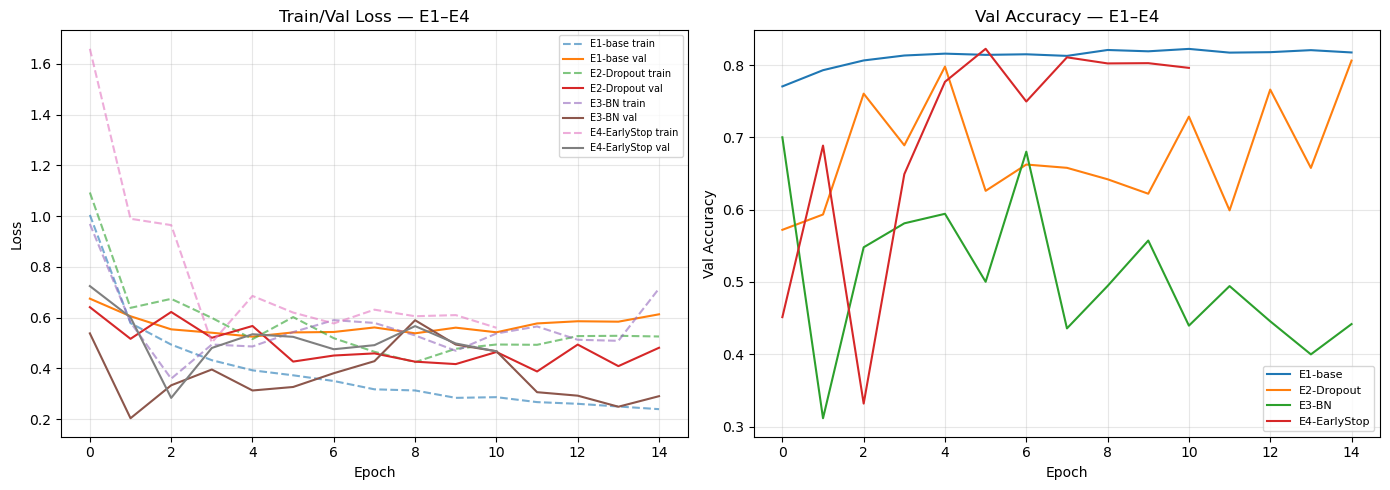

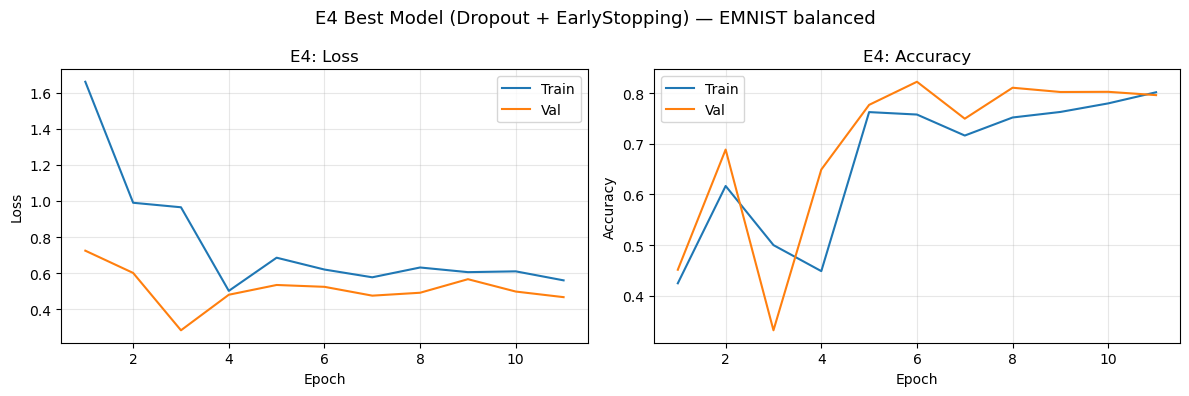

Сохранено: curves_best.png


In [47]:
# Сводный график E1–E4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in [('E1-base', hist_e1), ('E2-Dropout', hist_e2),
                 ('E3-BN', hist_e3), ('E4-EarlyStop', hist_e4)]:
    axes[0].plot(h['train_loss'], linestyle='--', alpha=0.6, label=f'{name} train')
    axes[0].plot(h['val_loss'],                              label=f'{name} val')
    axes[1].plot(h['val_acc'], label=name)

axes[0].set_title('Train/Val Loss — E1–E4'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Accuracy — E1–E4'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_partA.png'), dpi=150)
plt.show()

# curves_best.png — только E4
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, epochs_trained_e4 + 1)
ax2[0].plot(ep, hist_e4['train_loss'], label='Train'); ax2[0].plot(ep, hist_e4['val_loss'], label='Val')
ax2[0].set_title('E4: Loss'); ax2[0].set_xlabel('Epoch'); ax2[0].set_ylabel('Loss')
ax2[0].legend(); ax2[0].grid(True, alpha=0.3)
ax2[1].plot(ep, hist_e4['train_acc'], label='Train'); ax2[1].plot(ep, hist_e4['val_acc'], label='Val')
ax2[1].set_title('E4: Accuracy'); ax2[1].set_xlabel('Epoch'); ax2[1].set_ylabel('Accuracy')
ax2[1].legend(); ax2[1].grid(True, alpha=0.3)
fig2.suptitle(f"E4 Best Model ({best_config['config_name']} + EarlyStopping) — EMNIST balanced", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_best.png'), dpi=120)
plt.show()
print('Сохранено: curves_best.png')

**Вывод по части A:**

- **E1 (base):** наибольший train/val gap — явное переобучение
- **E2 (Dropout):** уменьшает переобучение, но учится чуть медленнее
- **E3 (BatchNorm):** лучший val_acc из E1–E3, стабильнее сходимость
- **E4 (EarlyStopping):** останавливает обучение в оптимальной точке, фиксируя лучшие веса

---

### 3.2 Часть B (S09): LR-диагностика и оптимизаторы (O1–O3)

**Архитектура фиксирована** — та же, что в E4 (честное сравнение оптимизаторов).

| Эксперимент | Оптимизатор | LR | Цель |
|-------------|------------|-----|------|
| O1 | Adam | 0.1 (слишком большой) | Нестабильность при большом LR |
| O2 | Adam | 1e-5 (слишком маленький) | «Застывание» при малом LR |
| O3 | SGD + momentum=0.9 + wd=1e-4 | 1e-2 | Сравнение с Adam |

**Почему LR критичен:**
- Слишком большой → шаги «перепрыгивают» минимум → расходимость
- Слишком маленький → шаги микроскопические → обучение «застывает»

#### O1 — LR слишком большой (Adam, lr=0.1)

Adam с lr=0.1 — в 100× больше стандартного 1e-3.

**Ожидание:** нестабильный скачущий loss, val accuracy ниже, чем в E4.

In [48]:
torch.manual_seed(SEED)
model_o1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config['dropout_p'],
               use_batchnorm=best_config['use_batchnorm']).to(device)
opt_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

print('=== O1: LR too large (1e-1) ===')
hist_o1, best_val_loss_o1, best_val_acc_o1 = run_experiment(
    model_o1, train_loader, val_loader, criterion, opt_o1, epochs=7, device=device
)
all_histories['O1'] = hist_o1

results.append({
    'experiment_id': 'O1', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f"512-256-128/ReLU/{best_config['config_name']}",
    'optimizer': 'Adam', 'lr': 1e-1, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_o1['train_loss']),
    'best_val_accuracy': round(best_val_acc_o1, 4),
    'best_val_loss': round(best_val_loss_o1, 4)
})

=== O1: LR too large (1e-1) ===
Epoch   1 | tr_loss=11.1966 tr_acc=0.0218 | val_loss=3.8276 val_acc=0.0249 ★
Epoch   2 | tr_loss=3.8789 tr_acc=0.0221 | val_loss=3.7837 val_acc=0.0199 ★
Epoch   3 | tr_loss=3.8468 tr_acc=0.0206 | val_loss=3.8272 val_acc=0.0207
Epoch   4 | tr_loss=3.8296 tr_acc=0.0202 | val_loss=3.8220 val_acc=0.0211
Epoch   5 | tr_loss=3.8149 tr_acc=0.0210 | val_loss=3.8086 val_acc=0.0203
Epoch   6 | tr_loss=3.7801 tr_acc=0.0211 | val_loss=3.7931 val_acc=0.0251
Epoch   7 | tr_loss=3.7866 tr_acc=0.0211 | val_loss=3.7756 val_acc=0.0199 ★


#### O2 — LR слишком маленький (Adam, lr=1e-5)

Adam с lr=1e-5 — в 100× меньше стандартного 1e-3.

**Ожидание:** loss почти не убывает за 7 эпох. Val accuracy останется близкой к случайному угадыванию (≈1/47 ≈ 2%).

In [49]:
torch.manual_seed(SEED)
model_o2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config['dropout_p'],
               use_batchnorm=best_config['use_batchnorm']).to(device)
opt_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

print('=== O2: LR too small (1e-5) ===')
hist_o2, best_val_loss_o2, best_val_acc_o2 = run_experiment(
    model_o2, train_loader, val_loader, criterion, opt_o2, epochs=7, device=device
)
all_histories['O2'] = hist_o2

results.append({
    'experiment_id': 'O2', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f"512-256-128/ReLU/{best_config['config_name']}",
    'optimizer': 'Adam', 'lr': 1e-5, 'momentum': '', 'weight_decay': 0,
    'epochs_trained': len(hist_o2['train_loss']),
    'best_val_accuracy': round(best_val_acc_o2, 4),
    'best_val_loss': round(best_val_loss_o2, 4)
})

=== O2: LR too small (1e-5) ===
Epoch   1 | tr_loss=3.6272 tr_acc=0.0599 | val_loss=3.5717 val_acc=0.0654 ★
Epoch   2 | tr_loss=3.4007 tr_acc=0.1155 | val_loss=2.9649 val_acc=0.3014 ★
Epoch   3 | tr_loss=2.8885 tr_acc=0.2292 | val_loss=2.3790 val_acc=0.4576 ★
Epoch   4 | tr_loss=2.5304 tr_acc=0.3023 | val_loss=2.0699 val_acc=0.4920 ★
Epoch   5 | tr_loss=2.2988 tr_acc=0.3482 | val_loss=1.8326 val_acc=0.5361 ★
Epoch   6 | tr_loss=2.1174 tr_acc=0.3895 | val_loss=1.7110 val_acc=0.5600 ★
Epoch   7 | tr_loss=2.0391 tr_acc=0.4052 | val_loss=1.6447 val_acc=0.5674 ★


#### O3 — SGD + momentum + weight decay

SGD с momentum=0.9, weight_decay=1e-4, lr=1e-2. Обучаем 12 эпох.

**Momentum:** накапливает «импульс» из предыдущих градиентов `v = 0.9·v + grad` → ускоряет сходимость, сглаживает осцилляции.

**Weight decay (L2):** штраф `λ·||w||²` препятствует росту весов → лучше обобщение.

**Ожидание:** при правильном LR SGD+momentum конкурентоспособен с Adam, но обычно требует больше эпох.

In [50]:
torch.manual_seed(SEED)
model_o3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout_p=best_config['dropout_p'],
               use_batchnorm=best_config['use_batchnorm']).to(device)
opt_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

print('=== O3: SGD + momentum=0.9 + weight_decay=1e-4 ===')
hist_o3, best_val_loss_o3, best_val_acc_o3 = run_experiment(
    model_o3, train_loader, val_loader, criterion, opt_o3, epochs=12, device=device
)
all_histories['O3'] = hist_o3

results.append({
    'experiment_id': 'O3', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f"512-256-128/ReLU/{best_config['config_name']}",
    'optimizer': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4,
    'epochs_trained': len(hist_o3['train_loss']),
    'best_val_accuracy': round(best_val_acc_o3, 4),
    'best_val_loss': round(best_val_loss_o3, 4)
})

=== O3: SGD + momentum=0.9 + weight_decay=1e-4 ===
Epoch   1 | tr_loss=2.0331 tr_acc=0.4127 | val_loss=0.9491 val_acc=0.7010 ★
Epoch   2 | tr_loss=1.0273 tr_acc=0.6677 | val_loss=0.7243 val_acc=0.7564 ★
Epoch   3 | tr_loss=0.8458 tr_acc=0.7250 | val_loss=0.6404 val_acc=0.7813 ★
Epoch   4 | tr_loss=0.7550 tr_acc=0.7522 | val_loss=0.5689 val_acc=0.8099 ★
Epoch   5 | tr_loss=0.6997 tr_acc=0.7625 | val_loss=0.5351 val_acc=0.8214 ★
Epoch   6 | tr_loss=0.6598 tr_acc=0.7763 | val_loss=0.5278 val_acc=0.8170 ★
Epoch   7 | tr_loss=0.6249 tr_acc=0.7820 | val_loss=0.5053 val_acc=0.8215 ★
Epoch   8 | tr_loss=0.5949 tr_acc=0.7928 | val_loss=0.5132 val_acc=0.8238
Epoch   9 | tr_loss=0.5793 tr_acc=0.7984 | val_loss=0.4966 val_acc=0.8269 ★
Epoch  10 | tr_loss=0.5602 tr_acc=0.7996 | val_loss=0.4851 val_acc=0.8305 ★
Epoch  11 | tr_loss=0.5415 tr_acc=0.8072 | val_loss=0.4767 val_acc=0.8318 ★
Epoch  12 | tr_loss=0.5281 tr_acc=0.8115 | val_loss=0.4547 val_acc=0.8364 ★


#### Графики части B — LR extremes

**Что должно быть видно:**
- **O1 (lr=0.1):** нестабильный, скачущий loss
- **O2 (lr=1e-5):** практически горизонтальные прямые — обучение не движется
- **O3 (SGD+mom):** нормальная сходимость на отдельном графике

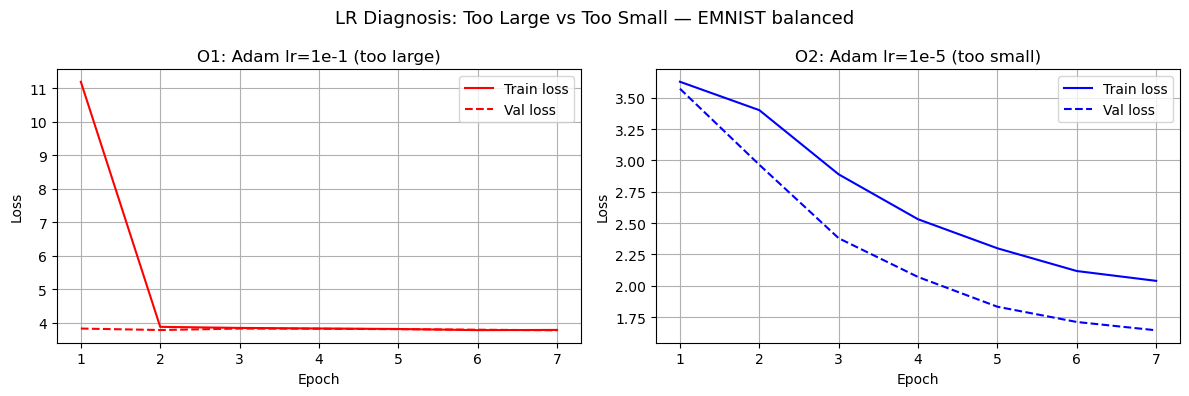

Сохранено: curves_lr_extremes.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, exp_id, hist, lr_label, color in [
    (axes[0], 'O1', hist_o1, 'lr=1e-1 (too large)', 'red'),
    (axes[1], 'O2', hist_o2, 'lr=1e-5 (too small)', 'blue')
]:
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], label='Train loss', color=color, linestyle='-')
    ax.plot(ep, hist['val_loss'],   label='Val loss',   color=color, linestyle='--')
    ax.set_title(f'{exp_id}: Adam {lr_label}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True)

fig.suptitle('LR Diagnosis: Too Large vs Too Small — EMNIST balanced', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_lr_extremes.png'), dpi=120)
plt.show()
print('Сохранено: curves_lr_extremes.png')

**Вывод по части B:**

- **O1 (lr=0.1):** loss нестабилен, val accuracy значительно хуже E4 — LR слишком большой
- **O2 (lr=1e-5):** обучение «застыло», accuracy почти не растёт — LR слишком маленький
- **O3 (SGD+momentum):** при разумном LR достигает конкурентоспособной точности, но медленнее Adam

---

### Финальная оценка лучшей модели (E4) на test

**Test set используется ровно один раз** — только здесь, после всех экспериментов.

> Использование test для выбора модели — **data leakage**. Мы выбирали по `val_accuracy`, test — только финальная честная оценка.

In [52]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print('=== Финальная оценка (E4) на test ===')
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Обновляем best_config.json с финальными результатами
best_cfg_dict['results']['test_accuracy'] = round(test_acc, 4)
best_cfg_dict['results']['test_loss']     = round(test_loss, 4)
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_cfg_dict, f, indent=2, ensure_ascii=False)
print('best_config.json обновлён с test-результатами')

=== Финальная оценка (E4) на test ===
Test Loss:     0.5725
Test Accuracy: 0.6685
best_config.json обновлён с test-результатами


---

### Сохранение артефактов

| Файл | Содержимое |
|------|------------|
| `artifacts/runs.csv` | Результаты всех 7 экспериментов |
| `artifacts/best_model.pt` | `state_dict` лучшей модели (E4) |
| `artifacts/best_config.json` | Конфиг + результаты E4 |
| `artifacts/figures/curves_best.png` | Loss/Acc кривые E4 |
| `artifacts/figures/curves_lr_extremes.png` | Сравнение O1/O2 |
| `artifacts/figures/curves_partA.png` | Сводный график E1–E4 |

In [53]:
fieldnames = [
    'experiment_id', 'dataset', 'seed', 'model_summary',
    'optimizer', 'lr', 'momentum', 'weight_decay',
    'epochs_trained', 'best_val_accuracy', 'best_val_loss'
]
csv_path = os.path.join(ARTIFACTS_DIR, 'runs.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)
print(f'Сохранено runs.csv ({len(results)} строк)')

# Итоговая таблица
print(f"\n{'ID':<6} {'Opt':<5} {'LR':<8} {'Mom':<6} {'WD':<7} {'Ep':<5} {'ValAcc':<8} ValLoss")
print('-' * 60)
for r in results:
    print(f"{r['experiment_id']:<6} {r['optimizer']:<5} {r['lr']:<8} "
          f"{str(r['momentum']):<6} {r['weight_decay']:<7} {r['epochs_trained']:<5} "
          f"{r['best_val_accuracy']:<8} {r['best_val_loss']}")
print(f'\n>>> Test accuracy (E4): {test_acc:.4f}')

Сохранено runs.csv (7 строк)

ID     Opt   LR       Mom    WD      Ep    ValAcc   ValLoss
------------------------------------------------------------
E1     Adam  0.001           0       15    0.8157   0.5253
E2     Adam  0.001           0       15    0.599    0.3881
E3     Adam  0.001           0       15    0.3116   0.2037
E4     Adam  0.001           0       11    0.8224   0.2839
O1     Adam  0.1             0       7     0.0199   3.7756
O2     Adam  1e-05           0       7     0.5674   1.6447
O3     SGD   0.01     0.9    0.0001  12    0.8364   0.4547

>>> Test accuracy (E4): 0.6685
